# Are Intermediate Arrow Tokens Task Vectors?

**Analysis 1:** For each arrow token in a 10-shot prompt, extract its hidden state at each layer,
patch into a zero-shot eval query (different from extraction query), measure accuracy.
One curve per arrow position. Each extraction is from a single prompt (not averaged).

**Analysis 2:** Causal necessity of IHs. Ablate IH outputs at a given arrow position during
the ICL forward pass, then extract the degraded hidden state, patch into zero-shot.
If accuracy drops, IH writes are necessary for that arrow token to function as a task vector.
One plot per arrow position: original curve vs ablated curve.

In [ ]:
import sys
sys.path.insert(0, '../..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random
import pickle

from transformer_lens import HookedTransformer
from configs import *
from utils import *

random.seed(SEED)
torch.manual_seed(SEED)
%matplotlib inline

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-25 19:21:34.513278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained(
    MODEL_NAME, device=DEVICE,
    dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
)
model.eval()
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
print(f'{n_layers}L, {n_heads}H, d={d_model}')

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.02it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
28L, 24H, d=3072


In [3]:
import pickle
with open('../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)
print(f'Loaded {len(all_splits)} tasks')


Loaded 20 tasks


In [4]:
# Identify IHs for ablation (output-attention criterion)
all_prompts_sub = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts'][:5]:
        all_prompts_sub.append(pdata)

attn_to_in, attn_to_out, attn_to_sep = extract_attention_patterns(model, all_prompts_sub)
output_attending_heads = select_top_heads(attn_to_out, percentile=90)
print(f'Output-attending heads (top 10%): {len(output_attending_heads)}')

# Organize by layer for hooking
ih_by_layer = defaultdict(list)
for l, h in output_attending_heads:
    ih_by_layer[l].append(h)

Attention patterns: 100%|██████████| 100/100 [00:05<00:00, 17.95it/s]

Output-attending heads (top 10%): 68


## Analysis 1: Patching each arrow token's hidden state into zero-shot

For each ICL prompt:
1. Run forward pass, cache residual stream
2. For each arrow/separator position (→ after demo 1, ..., → after demo 10, final →):
   extract hidden state at every layer
3. For each eval query: patch that hidden state into zero-shot at the final position, check accuracy
4. Average accuracy across eval queries

Then average across prompts (accuracy, not vectors).

In [6]:
# Load if exists
with open('arrow_accs.pkl', 'rb') as f:
    arrow_accs = pickle.load(f)
print(f'Loaded {len(arrow_accs)} arrow positions')

Loaded 11 arrow positions


In [7]:
# Don't run if previous cell ran

N_PROMPTS = 10
RESID_FILTER = lambda name: 'resid_post' in name

# ── Phase 1: Extract hidden states at all 11 arrow positions ────────
print("Phase 1: Extracting hidden states\n")
extracted = {}

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    n_prompts = min(N_PROMPTS, len(splits['icl_prompts']))
    print(f'[{t_idx+1}/{len(all_splits)}] {task_name} ({n_prompts} prompts)')
    extracted[task_name] = {}
    
    for p_idx, pdata in enumerate(tqdm(splits['icl_prompts'][:N_PROMPTS], desc=f'  extracting')):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
        
        # arrow_idx 0..9 = demo separators, arrow_idx 10 = final query arrow
        arrow_vecs = defaultdict(dict)  # arrow_idx -> layer -> vec
        for layer in range(n_layers):
            h_all = cache['resid_post', layer][0].cpu().float()
            for demo_idx, demo_info in enumerate(per_demo):
                sep_pos = demo_info['separator_positions']
                if sep_pos:
                    arrow_vecs[demo_idx][layer] = h_all[sep_pos[-1]].numpy()
            arrow_vecs[len(per_demo)][layer] = h_all[last_pos].numpy()
        
        extracted[task_name][p_idx] = arrow_vecs
        del cache
        torch.cuda.empty_cache()

n_arrows = len(per_demo) + 1  # 10 demo arrows + 1 query arrow
print(f'\nExtracted. {n_arrows} arrow positions per prompt.\n')

Phase 1: Extracting hidden states

[1/20] knowledge/country_capital (10 prompts)


  extracting: 100%|██████████| 10/10 [00:00<00:00, 16.59it/s]


[2/20] knowledge/football_player_position (10 prompts)


  extracting: 100%|██████████| 10/10 [00:00<00:00, 17.32it/s]


[3/20] knowledge/location_continent (10 prompts)


...

[19/20] translation/fr_en (10 prompts)


  extracting: 100%|██████████| 10/10 [00:00<00:00, 17.08it/s]


[20/20] translation/it_en (10 prompts)


  extracting: 100%|██████████| 10/10 [00:00<00:00, 17.05it/s]


Extracted. 11 arrow positions per prompt.



In [7]:
# ── Phase 2: Evaluate ──────────────────────────────────────────────
import time
print("Phase 2: Patching into zero-shot\n")

arrow_accs = defaultdict(lambda: defaultdict(list))

total_patches = len(all_splits) * n_arrows * N_PROMPTS * n_layers
patches_done = 0
t_start = time.time()

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    n_prompts = min(N_PROMPTS, len(splits['icl_prompts']))
    print(f'{"="*60}')
    print(f'TASK [{t_idx+1}/{len(all_splits)}]: {task_name}')
    print(f'{"="*60}')
    
    for arrow_idx in range(n_arrows):
        if arrow_idx < n_arrows - 1:
            label = f'arrow {arrow_idx+1}/{n_arrows} (after demo {arrow_idx+1})'
        else:
            label = f'arrow {n_arrows}/{n_arrows} (query position)'
        
        task_arrow_by_layer = defaultdict(list)
        for p_idx in range(n_prompts):
            eq = eval_data[p_idx % len(eval_data)]
            if arrow_idx not in extracted[task_name][p_idx]:
                patches_done += n_layers
                continue
            for layer in range(n_layers):
                if layer not in extracted[task_name][p_idx][arrow_idx]:
                    patches_done += 1
                    continue
                theta = extracted[task_name][p_idx][arrow_idx][layer]
                logits = eval_patched_resid(model, eq['zs_prompt'], theta, layer)
                correct = float(check_correct(model, logits, eq['query_output']))
                arrow_accs[arrow_idx][layer].append(correct)
                task_arrow_by_layer[layer].append(correct)
                patches_done += 1
        
        elapsed = time.time() - t_start
        rate = patches_done / elapsed if elapsed > 0 else 0
        eta = (total_patches - patches_done) / rate if rate > 0 else 0
        
        print(f'\n  {label}:  [{patches_done}/{total_patches}, {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining]')
        for layer in range(n_layers):
            if task_arrow_by_layer[layer]:
                acc = np.mean(task_arrow_by_layer[layer])
                print(f'    layer {layer:2d}: {acc:.3f}  {"█" * int(acc * 20)}')
        
        if task_arrow_by_layer:
            peak_l = max(task_arrow_by_layer, key=lambda l: np.mean(task_arrow_by_layer[l]) if task_arrow_by_layer[l] else 0)
            print(f'  ── summary: peak layer={peak_l}, acc={np.mean(task_arrow_by_layer[peak_l]):.3f}')
    
    print()

print(f'Done. {patches_done} patches in {time.time() - t_start:.0f}s')

Phase 2: Patching into zero-shot

TASK [1/20]: knowledge/country_capital

  arrow 1/11 (after demo 1):  [280/61600, 11s elapsed, ~2423s remaining]
    layer  0: 0.000  
    layer  1: 0.000  
    layer  2: 0.000  
    layer  3: 0.000  
    layer  4: 0.000  
    layer  5: 0.000  
    layer  6: 0.000  
    layer  7: 0.000  
    layer  8: 0.000  
    layer  9: 0.000  
    layer 10: 0.000  
    layer 11: 0.000  
    layer 12: 0.000  
    layer 13: 0.000  
    layer 14: 0.000  
    layer 15: 0.000  
    layer 16: 0.000  
    layer 17: 0.000  
    layer 18: 0.000  
    layer 19: 0.000  
    layer 20: 0.000  
    layer 21: 0.000  
    layer 22: 0.000  
    layer 23: 0.000  
    layer 24: 0.000  
    layer 25: 0.000  
    layer 26: 0.000  
    layer 27: 0.000  
  ── summary: peak layer=0, acc=0.000

  arrow 2/11 (after demo 2):  [560/61600, 22s elapsed, ~2416s remaining]
    layer  0: 0.000  
    layer  1: 0.100  ██
    layer  2: 0.200  ████
    layer  3: 0.200  ████
    layer  4: 0.200  ████
 

In [22]:
# Save
out = 'arrow_accs.pkl'
save_data = {k: dict(v) for k, v in arrow_accs.items()}
with open(out, 'wb') as f:
    pickle.dump(save_data, f)
print(f'\nSaved to {out}')


Saved to arrow_accs.pkl


In [13]:
# Baselines
icl_correct, zs_correct = [], []
for task_name, splits in all_splits.items():
    for eq in splits['eval_data']:
        with torch.no_grad():
            icl_logits = model(model.to_tokens(eq['icl_prompt'], prepend_bos=True))[0, -1]
            icl_correct.append(float(check_correct(model, icl_logits, eq['query_output'])))
            zs_logits = model(model.to_tokens(eq['zs_prompt'], prepend_bos=True))[0, -1]
            zs_correct.append(float(check_correct(model, zs_logits, eq['query_output'])))
avg_icl = np.mean(icl_correct)
avg_zs = np.mean(zs_correct)
print(f'ICL: {avg_icl:.3f}, Zero-shot: {avg_zs:.3f} ({len(icl_correct)} queries across {len(all_splits)} tasks)')

ICL: 0.850, Zero-shot: 0.010 (400 queries across 20 tasks)


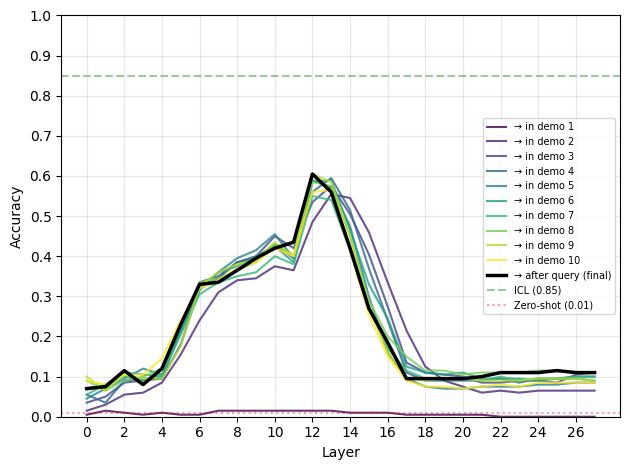

Position                         Peak acc   Peak layer
-------------------------------------------------------
→ in demo 1                         0.015            1
→ in demo 2                         0.555           13
→ in demo 3                         0.575           13
→ in demo 4                         0.595           13
→ in demo 5                         0.590           12
→ in demo 6                         0.590           13
→ in demo 7                         0.550           12
→ in demo 8                         0.585           12
→ in demo 9                         0.605           12
→ in demo 10                        0.565           13
→ after query (final)               0.605           12


In [24]:
# Plot: one curve per arrow position
fig, ax = plt.subplots(figsize = (6.4, 4.8))
layers = list(range(n_layers))

cmap = plt.cm.viridis
for arrow_idx in sorted(arrow_accs.keys()):
    curve = [np.mean(arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    if arrow_idx == n_arrows - 1:
        ax.plot(layers, curve, 'k-', lw=2.5, label='→ after query (final)', zorder=10)
    else:
        color = cmap(arrow_idx / max(n_arrows - 2, 1))
        ax.plot(layers, curve, '-', color=color, lw=1.5, alpha=0.8,
                label=f'→ in demo {arrow_idx+1}')

ax.axhline(avg_icl, ls='--', color='green', alpha=0.4, label=f'ICL ({avg_icl:.2f})')
ax.axhline(avg_zs, ls=':', color='red', alpha=0.4, label=f'Zero-shot ({avg_zs:.2f})')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc='best')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Summary table
print(f'{"Position":30s} {"Peak acc":>10s} {"Peak layer":>12s}')
print('-' * 55)
for arrow_idx in sorted(arrow_accs.keys()):
    curve = [np.mean(arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    label = '→ after query (final)' if arrow_idx == n_arrows - 1 else f'→ in demo {arrow_idx+1}'
    print(f'{label:30s} {max(curve):10.3f} {int(np.argmax(curve)):12d}')

## Analysis 2: Causal necessity of IH writes

For each arrow position, run the ICL forward pass with IH outputs **zeroed at that position**.
Extract the degraded arrow hidden state, patch into zero-shot, measure accuracy.

If accuracy drops relative to the unablated curve, IH writes are causally necessary
for that arrow token to function as a task vector.

One plot per arrow position: original curve vs ablated curve.

In [27]:
# For each arrow position, extract hidden states from ablated forward passes.
# Ablation: zero out output-attending heads' outputs at the target arrow position only.
import time

ablated_arrow_accs = defaultdict(lambda: defaultdict(list))

total_patches = len(all_splits) * n_arrows * N_PROMPTS * n_layers
patches_done = 0
t_start = time.time()

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    n_prompts = min(N_PROMPTS, len(splits['icl_prompts']))
    print(f'{"="*60}')
    print(f'TASK [{t_idx+1}/{len(all_splits)}]: {task_name}')
    print(f'{"="*60}')
    
    for arrow_idx in range(n_arrows):
        if arrow_idx < n_arrows - 1:
            label = f'arrow {arrow_idx+1}/{n_arrows} (in demo {arrow_idx+1})'
        else:
            label = f'arrow {n_arrows}/{n_arrows} (after query)'
        
        task_arrow_by_layer = defaultdict(list)
        for p_idx in range(n_prompts):
            eq = eval_data[p_idx % len(eval_data)]
            pdata = splits['icl_prompts'][p_idx]
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            last_pos = tokens.shape[1] - 1
            per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
            
            # Find target position
            if arrow_idx < len(per_demo):
                sep_pos = per_demo[arrow_idx]['separator_positions']
                if not sep_pos:
                    patches_done += n_layers
                    continue
                target_pos = sep_pos[-1]
            else:
                target_pos = last_pos
            
            # Build hooks: zero out IH outputs at target_pos only
            fwd_hooks = []
            for l, h_list in ih_by_layer.items():
                def ablate_hook(z, hook, _h_list=h_list, _pos=target_pos):
                    for h in _h_list:
                        z[0, _pos, h, :] = 0
                    return z
                fwd_hooks.append((f'blocks.{l}.attn.hook_z', ablate_hook))
            
            with model.hooks(fwd_hooks=fwd_hooks):
                _, cache = model.run_with_cache(
                    tokens, names_filter=RESID_FILTER
                )
            
            for layer in range(n_layers):
                h_all = cache['resid_post', layer][0].cpu().float()
                theta_abl = h_all[target_pos].numpy()
                logits = eval_patched_resid(model, eq['zs_prompt'], theta_abl, layer)
                correct = float(check_correct(model, logits, eq['query_output']))
                ablated_arrow_accs[arrow_idx][layer].append(correct)
                task_arrow_by_layer[layer].append(correct)
                patches_done += 1
            
            del cache
            torch.cuda.empty_cache()
        
        elapsed = time.time() - t_start
        rate = patches_done / elapsed if elapsed > 0 else 0
        eta = (total_patches - patches_done) / rate if rate > 0 else 0
        
        print(f'\n  {label}:  [{patches_done}/{total_patches}, {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining]')
        for layer in range(n_layers):
            if task_arrow_by_layer[layer]:
                acc = np.mean(task_arrow_by_layer[layer])
                print(f'    layer {layer:2d}: {acc:.3f}  {"█" * int(acc * 20)}')
        
        if task_arrow_by_layer:
            peak_l = max(task_arrow_by_layer, key=lambda l: np.mean(task_arrow_by_layer[l]) if task_arrow_by_layer[l] else 0)
            print(f'  ── summary: peak layer={peak_l}, acc={np.mean(task_arrow_by_layer[peak_l]):.3f}')
    
    print()

print(f'Done. {patches_done} patches in {time.time() - t_start:.0f}s')

TASK [1/20]: knowledge/country_capital

  arrow 1/11 (in demo 1):  [280/61600, 14s elapsed, ~2996s remaining]
    layer  0: 0.000  
    layer  1: 0.000  
    layer  2: 0.000  
    layer  3: 0.000  
    layer  4: 0.000  
    layer  5: 0.000  
    layer  6: 0.000  
    layer  7: 0.000  
    layer  8: 0.000  
    layer  9: 0.000  
    layer 10: 0.000  
    layer 11: 0.000  
    layer 12: 0.000  
    layer 13: 0.000  
    layer 14: 0.000  
    layer 15: 0.000  
    layer 16: 0.000  
    layer 17: 0.000  
    layer 18: 0.000  
    layer 19: 0.000  
    layer 20: 0.000  
    layer 21: 0.000  
    layer 22: 0.000  
    layer 23: 0.000  
    layer 24: 0.000  
    layer 25: 0.000  
    layer 26: 0.000  
    layer 27: 0.000  
  ── summary: peak layer=0, acc=0.000

  arrow 2/11 (in demo 2):  [560/61600, 27s elapsed, ~2956s remaining]
    layer  0: 0.000  
    layer  1: 0.100  ██
    layer  2: 0.200  ████
    layer  3: 0.400  ████████
    layer  4: 0.100  ██
    layer  5: 0.100  ██
    layer  6: 0

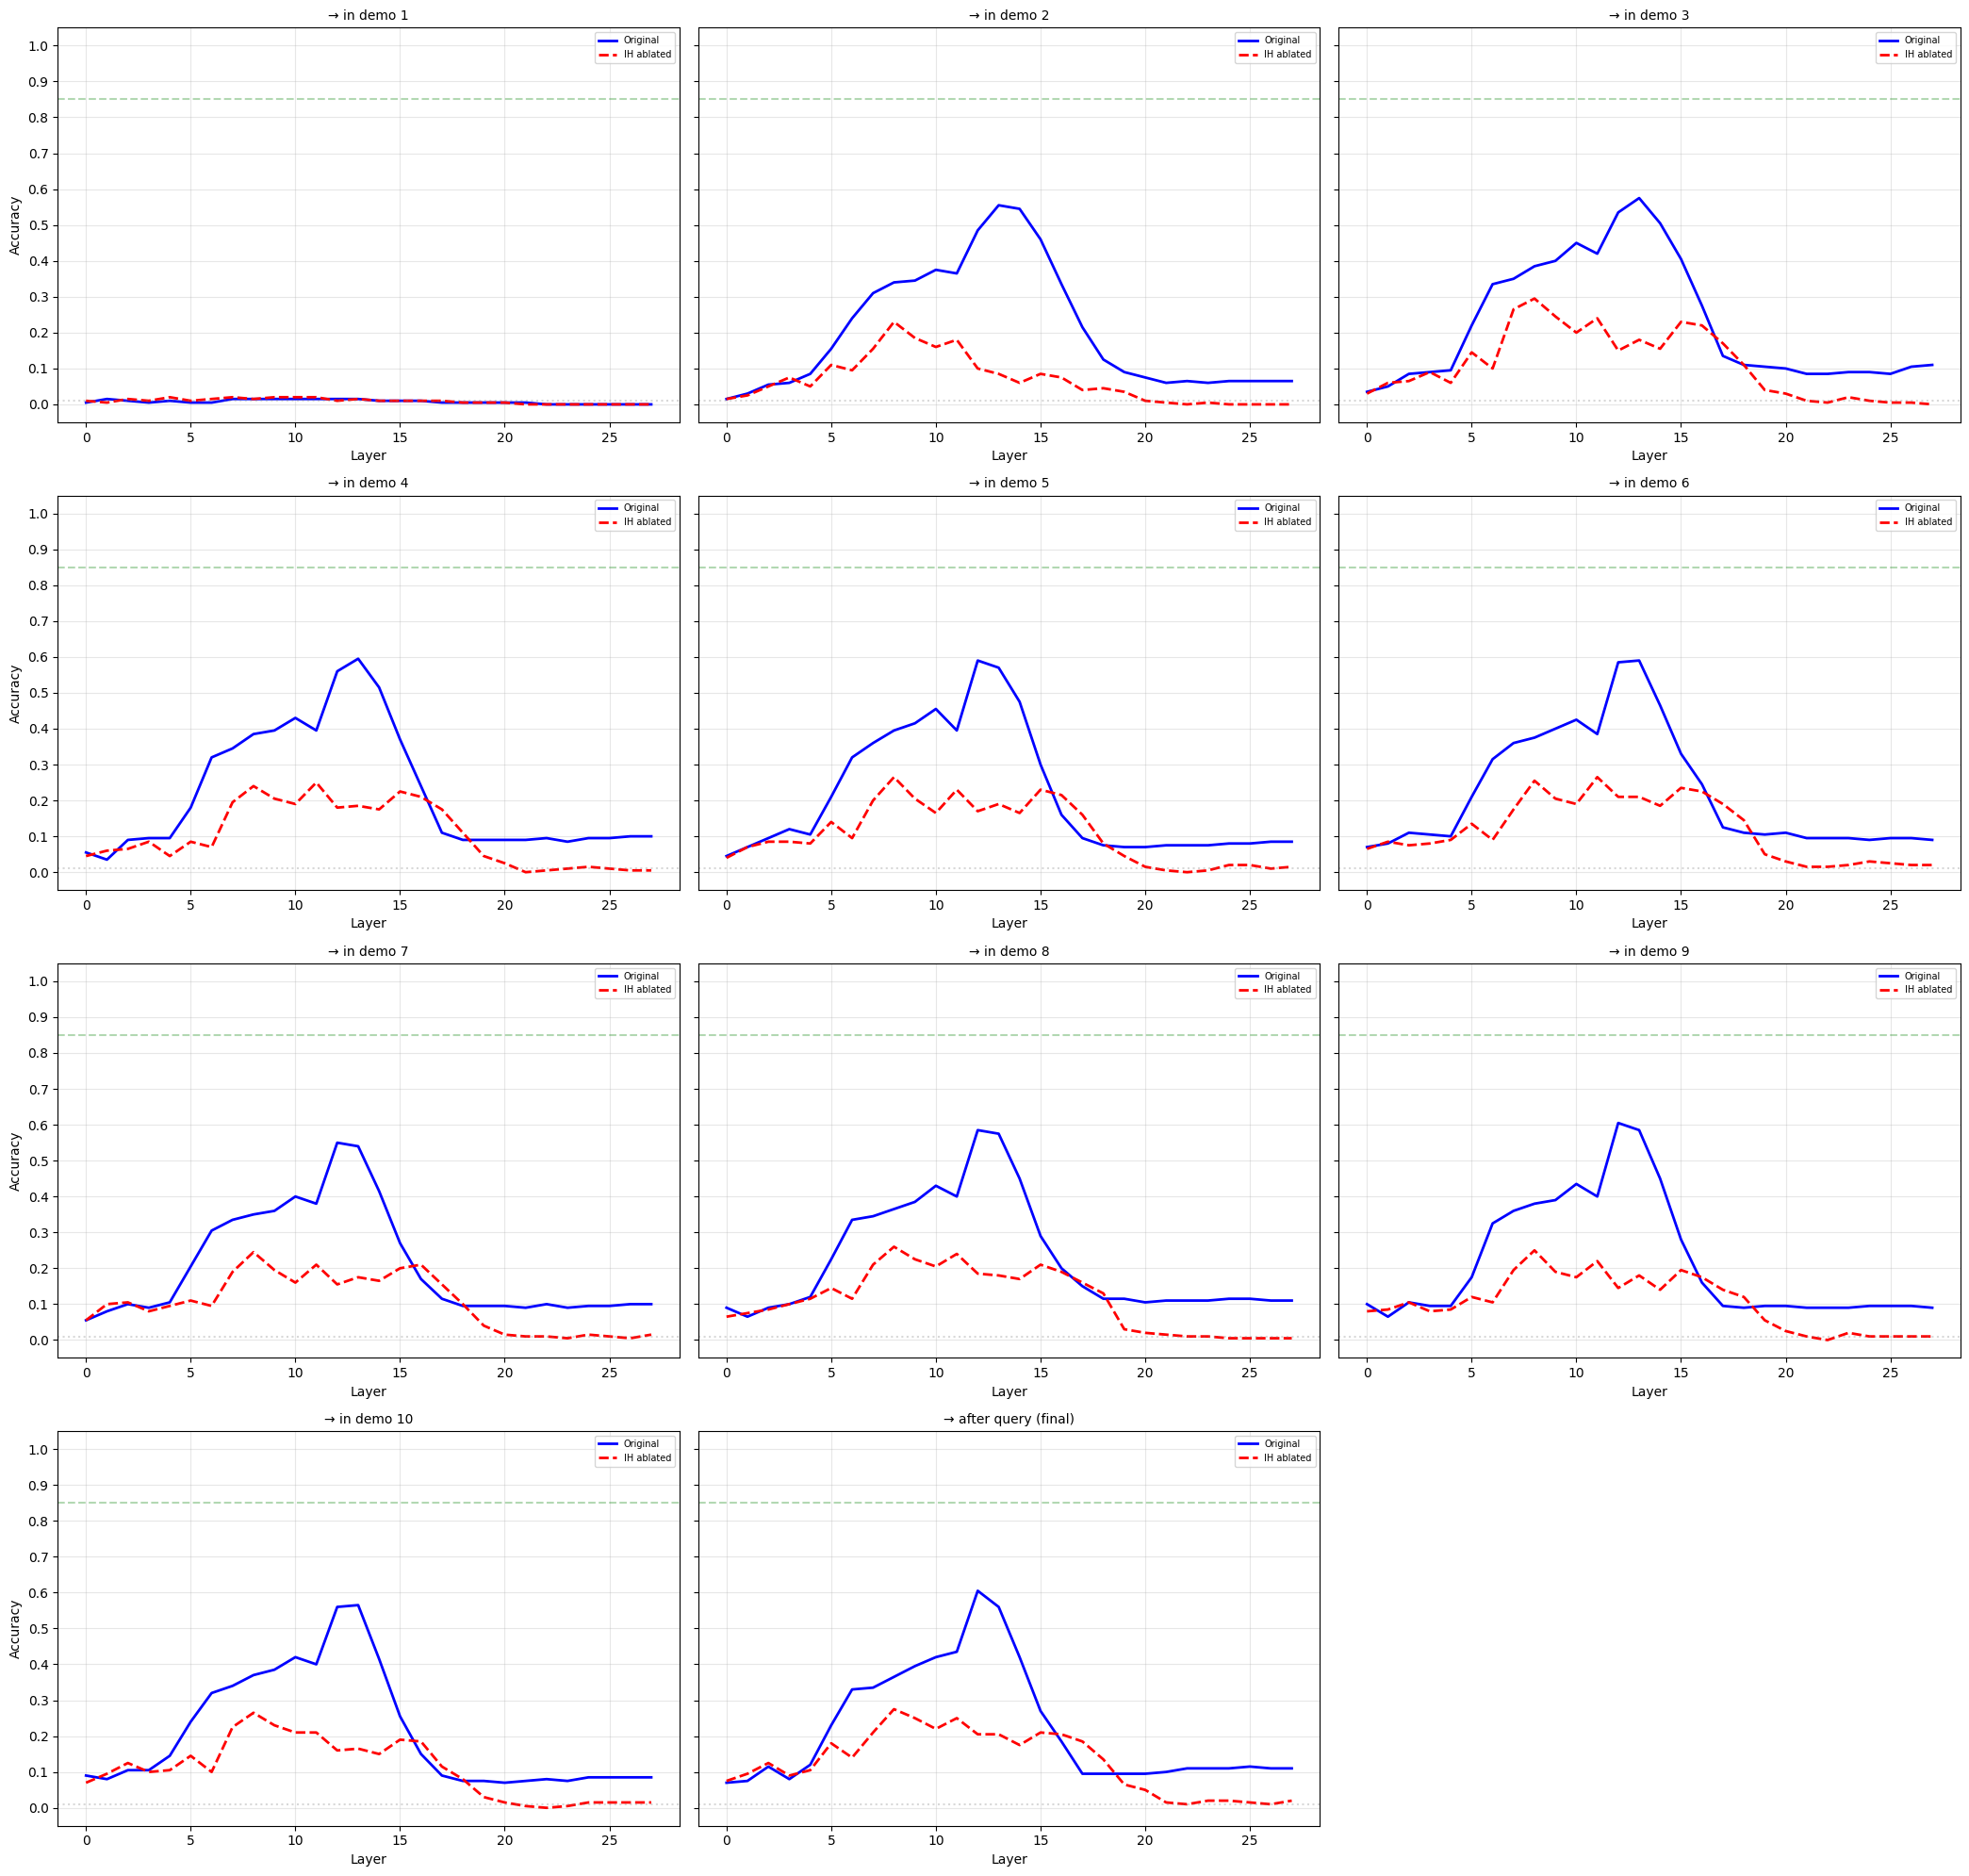

In [29]:
# One plot per arrow position: original vs ablated
n_plots = n_arrows
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), sharey=True)
axes = axes.flatten()

for arrow_idx in range(n_arrows):
    ax = axes[arrow_idx]
    
    orig_curve = [np.mean(arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    abl_curve = [np.mean(ablated_arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    
    if arrow_idx == n_arrows - 1:
        title = '→ after query (final)'
    else:
        title = f'→ in demo {arrow_idx + 1}'
    
    ax.plot(layers, orig_curve, 'b-', lw=2, label='Original')
    ax.plot(layers, abl_curve, 'r--', lw=2, label='IH ablated')
    ax.axhline(avg_icl, ls='--', color='green', alpha=0.3)
    ax.axhline(avg_zs, ls=':', color='gray', alpha=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Layer')
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, alpha=0.3)
    if arrow_idx % n_cols == 0:
        ax.set_ylabel('Accuracy')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)

for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Save ablation results
save_ablated = {k: dict(v) for k, v in ablated_arrow_accs.items()}
with open('ablated_arrow_accs.pkl', 'wb') as f:
    pickle.dump(save_ablated, f)
print('Saved ablated_arrow_accs.pkl')

In [ ]:
# Load ablation results
with open('ablated_arrow_accs.pkl', 'rb') as f:
    ablated_arrow_accs = pickle.load(f)
print(f'Loaded {len(ablated_arrow_accs)} ablated arrow positions')

In [ ]:
# Summary: peak accuracy drop from ablation
print(f'{"Position":30s} {"Peak (orig)":>12s} {"Peak (ablated)":>15s} {"Drop":>8s}')
print('-' * 68)
for arrow_idx in range(n_arrows):
    orig = [np.mean(arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    abl = [np.mean(ablated_arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    label = '→ after query (final)' if arrow_idx == n_arrows - 1 else f'→ in demo {arrow_idx+1}'
    print(f'{label:30s} {max(orig):12.3f} {max(abl):15.3f} {max(orig)-max(abl):8.3f}')

## Analysis 3: Causal sufficiency of IH outputs

For each arrow position, extract ONLY the IH outputs (W_O @ hook_z) at that position,
sum them, and ADD that sum to the zero-shot residual stream at each layer.
If accuracy is high, IH outputs alone are sufficient to create the task vector effect.

One curve per arrow position, same format as Analysis 1.

In [9]:
# Causal sufficiency: do IH outputs at each arrow position alone recover task vector performance?
import time

HEAD_Z_FILTER = lambda name: 'hook_z' in name

sufficiency_arrow_accs = defaultdict(lambda: defaultdict(list))

total_patches = len(all_splits) * n_arrows * N_PROMPTS * n_layers
patches_done = 0
t_start = time.time()

for t_idx, (task_name, splits) in enumerate(all_splits.items()):
    eval_data = splits['eval_data']
    n_prompts = min(N_PROMPTS, len(splits['icl_prompts']))
    print(f'{"="*60}')
    print(f'TASK [{t_idx+1}/{len(all_splits)}]: {task_name}')
    print(f'{"="*60}')
    
    for p_idx in range(n_prompts):
        pdata = splits['icl_prompts'][p_idx]
        eq = eval_data[p_idx % len(eval_data)]
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=HEAD_Z_FILTER)
        
        for arrow_idx in range(n_arrows):
            # Find target position
            if arrow_idx < len(per_demo):
                sep_pos = per_demo[arrow_idx]['separator_positions']
                if not sep_pos:
                    patches_done += n_layers
                    continue
                target_pos = sep_pos[-1]
            else:
                target_pos = last_pos
            
            # For each layer, sum IH outputs at target_pos from heads in that layer
            for layer in range(n_layers):
                ih_sum = np.zeros(d_model)
                for l, h in output_attending_heads:
                    if l != layer:
                        continue
                    z = cache[f'blocks.{l}.attn.hook_z'][0, target_pos, h].cpu().float().numpy()
                    W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
                    ih_sum += W_O.T @ z
                
                logits = eval_patched_resid_add(model, eq['zs_prompt'], ih_sum, layer)
                correct = float(check_correct(model, logits, eq['query_output']))
                sufficiency_arrow_accs[arrow_idx][layer].append(correct)
                patches_done += 1
        
        del cache
        torch.cuda.empty_cache()
    
    # Print per-task summary
    for arrow_idx in range(n_arrows):
        label = f'arrow {n_arrows}/{n_arrows} (after query)' if arrow_idx == n_arrows - 1 else f'arrow {arrow_idx+1}/{n_arrows} (in demo {arrow_idx+1})'
        d = sufficiency_arrow_accs[arrow_idx]
        if d:
            peak_l = max(range(n_layers), key=lambda l: np.mean(d.get(l, [0])))
            elapsed = time.time() - t_start
            rate = patches_done / elapsed if elapsed > 0 else 0
            eta = (total_patches - patches_done) / rate if rate > 0 else 0
            print(f'  {label}: peak L{peak_l}={np.mean(d.get(peak_l, [0])):.3f}  [{patches_done}/{total_patches}, ~{eta:.0f}s remaining]')
    print()

print(f'Done. {patches_done} patches in {time.time() - t_start:.0f}s')

TASK [1/20]: knowledge/country_capital
  arrow 1/11 (in demo 1): peak L0=0.000  [3080/61600, ~2711s remaining]
  arrow 2/11 (in demo 2): peak L12=0.500  [3080/61600, ~2711s remaining]
  arrow 3/11 (in demo 3): peak L12=0.800  [3080/61600, ~2711s remaining]
  arrow 4/11 (in demo 4): peak L12=0.700  [3080/61600, ~2711s remaining]
  arrow 5/11 (in demo 5): peak L12=0.800  [3080/61600, ~2711s remaining]
  arrow 6/11 (in demo 6): peak L12=0.600  [3080/61600, ~2711s remaining]
  arrow 7/11 (in demo 7): peak L12=0.600  [3080/61600, ~2711s remaining]
  arrow 8/11 (in demo 8): peak L12=0.700  [3080/61600, ~2711s remaining]
  arrow 9/11 (in demo 9): peak L12=0.600  [3080/61600, ~2711s remaining]
  arrow 10/11 (in demo 10): peak L14=0.600  [3080/61600, ~2711s remaining]
  arrow 11/11 (after query): peak L14=0.600  [3080/61600, ~2711s remaining]

TASK [2/20]: knowledge/football_player_position
  arrow 1/11 (in demo 1): peak L0=0.000  [6160/61600, ~2632s remaining]
  arrow 2/11 (in demo 2): peak L1

In [10]:
# Save sufficiency results
save_sufficiency = {k: dict(v) for k, v in sufficiency_arrow_accs.items()}
with open('sufficiency_arrow_accs.pkl', 'wb') as f:
    pickle.dump(save_sufficiency, f)
print('Saved sufficiency_arrow_accs.pkl')

Saved sufficiency_arrow_accs.pkl


In [11]:
# Load sufficiency results
with open('sufficiency_arrow_accs.pkl', 'rb') as f:
    sufficiency_arrow_accs = pickle.load(f)
print(f'Loaded {len(sufficiency_arrow_accs)} sufficiency arrow positions')

Loaded 11 sufficiency arrow positions


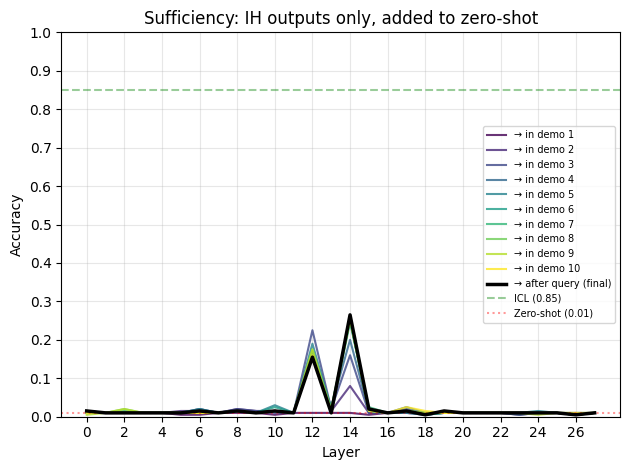

Position                         Peak acc   Peak layer
-------------------------------------------------------
→ in demo 1                         0.010            0
→ in demo 2                         0.170           12
→ in demo 3                         0.225           12
→ in demo 4                         0.200           14
→ in demo 5                         0.255           14
→ in demo 6                         0.250           14
→ in demo 7                         0.245           14
→ in demo 8                         0.255           14
→ in demo 9                         0.255           14
→ in demo 10                        0.260           14
→ after query (final)               0.265           14


In [14]:
# Plot: sufficiency — one curve per arrow position
fig, ax = plt.subplots()
layers = list(range(n_layers))

cmap = plt.cm.viridis
for arrow_idx in sorted(sufficiency_arrow_accs.keys()):
    curve = [np.mean(sufficiency_arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    if arrow_idx == n_arrows - 1:
        ax.plot(layers, curve, 'k-', lw=2.5, label='→ after query (final)', zorder=10)
    else:
        color = cmap(arrow_idx / max(n_arrows - 2, 1))
        ax.plot(layers, curve, '-', color=color, lw=1.5, alpha=0.8,
                label=f'→ in demo {arrow_idx+1}')

ax.axhline(avg_icl, ls='--', color='green', alpha=0.4, label=f'ICL ({avg_icl:.2f})')
ax.axhline(avg_zs, ls=':', color='red', alpha=0.4, label=f'Zero-shot ({avg_zs:.2f})')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, loc='best')
ax.set_ylim(0, 1)
ax.set_title('Sufficiency: IH outputs only, added to zero-shot')
plt.tight_layout()
plt.show()

# Summary table
print(f'{"Position":30s} {"Peak acc":>10s} {"Peak layer":>12s}')
print('-' * 55)
for arrow_idx in sorted(sufficiency_arrow_accs.keys()):
    curve = [np.mean(sufficiency_arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    label = '→ after query (final)' if arrow_idx == n_arrows - 1 else f'→ in demo {arrow_idx+1}'
    print(f'{label:30s} {max(curve):10.3f} {int(np.argmax(curve)):12d}')

In [18]:
# Combined summary: original, ablated (necessity), sufficiency
print(f'{"Position":25s} {"Original":>10s} {"IH ablated":>12s} {"Drop":>8s} {"IH only":>10s}')
print('-' * 70)
for arrow_idx in range(n_arrows):
    orig = [np.mean(arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    abl = [np.mean(ablated_arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    suf = [np.mean(sufficiency_arrow_accs[arrow_idx].get(l, [0])) for l in layers]
    label = '→ query (final)' if arrow_idx == n_arrows - 1 else f'→ demo {arrow_idx+1}'
    print(f'{label:25s} {max(orig):10.3f} {max(abl):12.3f} {max(orig)-max(abl):8.3f} {max(suf):10.3f}')

Position                    Original   IH ablated     Drop    IH only
----------------------------------------------------------------------
→ demo 1                       0.015        0.015    0.000      0.010
→ demo 2                       0.555        0.555    0.000      0.170
→ demo 3                       0.575        0.575    0.000      0.225
→ demo 4                       0.595        0.595    0.000      0.200
→ demo 5                       0.590        0.590    0.000      0.255
→ demo 6                       0.590        0.590    0.000      0.250
→ demo 7                       0.550        0.550    0.000      0.245
→ demo 8                       0.585        0.585    0.000      0.255
→ demo 9                       0.605        0.605    0.000      0.255
→ demo 10                      0.565        0.565    0.000      0.260
→ query (final)                0.605        0.605    0.000      0.265
